# 7.1.2 传感器与可区分的状态

## 学习目标与先修知识

构造能观矩阵（matrix），解释秩（rank）、采样（sampling）和噪声放大各自决定的问题。

先修：7.1.1的状态（state）与观测（observation）区分，以及第3篇矩阵秩和线性方程组（system of linear equations）。 [本篇学习次序](../README.md)。

## 具体问题

两个组织室总量都是10U，但初态分别为[8,2]和[2,8]。只测总量能知道哪一室更多吗？把传感器移到第一室后，情况为什么改变？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
F=np.array([[.8,.2],[.2,.8]])
for H in [np.array([1.,1.]),np.array([1.,0.])]:
    print('H=',H,'两个初态读数=',H@np.array([8.,2.]),H@np.array([2.,8.]))

H= [1. 1.] 两个初态读数= 10.0 10.0
H= [1. 0.] 两个初态读数= 8.0 2.0


## 模型假设

线性离散模型（model）的矩阵已知，观测无噪声，目标是由读数恢复未知初态。两个状态使用相同所追踪物质总量（tracked amount）单位。有限时域（finite horizon）长度表示观察次数，包含时刻0。数值秩需给阈值；这里奇异值（singular value）阈值固定1e−10，教学比较远离阈值边界。

## 数学解释与推导

逐次代入得到 $y_0=Hx_0$、$y_1=HFx_0$，于是
$$\begin{bmatrix}y_0\\y_1\\\vdots\\y_{L-1}\end{bmatrix}=\mathcal O_Lx_0,\quad
\mathcal O_L=\begin{bmatrix}H\\HF\\\vdots\\HF^{L-1}\end{bmatrix}.$$
两个初态差 $d$ 无法被区分，当且仅当 $\mathcal O_Ld=0$。能观性（observability）也称可观测性，要求能观矩阵满列秩。对两室例子：
$$H=[1,0]\Rightarrow\mathcal O_2=\begin{bmatrix}1&0\\.8&.2\end{bmatrix},\quad\det=.2;$$
$$H=[1,1]\Rightarrow\mathcal O_2=\begin{bmatrix}1&1\\1&1\end{bmatrix},\quad\mathcal O_2[1,-1]^T=0.$$
满秩说明无噪唯一性；并不保证含噪反演稳健。奇异值刻画矩阵沿不同方向的放大，最小奇异值很小时，反演会放大噪声。采样也改变F：完整周期采样旋转运动得到F=I时，只测第一坐标仍不能恢复第二坐标。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型与当时可用的信息。

In [3]:
def observability(transition, sensor, horizon, initial):
    F, H = np.array(transition, float), np.array(sensor, float)
    rows, power = [], np.eye(len(initial))
    for _ in range(horizon):
        rows.append(H @ power)
        power = power @ F
    matrix = np.array(rows).reshape(horizon, len(initial))
    rank = int(np.linalg.matrix_rank(matrix, tol=1e-10)) if horizon else 0
    return matrix.tolist(), (matrix @ initial).tolist(), rank

## 对照实验

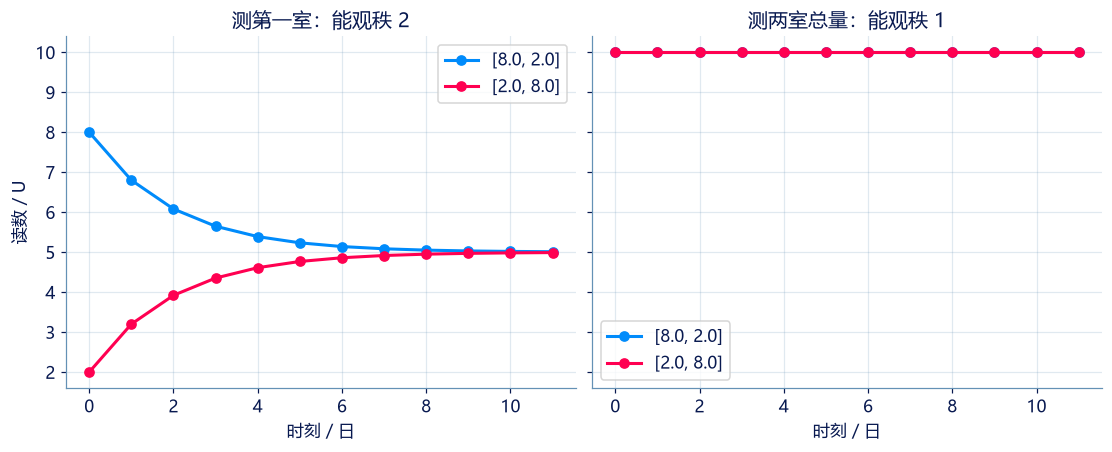

In [4]:
F=[[.8,.2],[.2,.8]]
fig,axes=plt.subplots(1,2,figsize=(10,4),sharey=True)
for ax,H,title in zip(axes,[[1.,0.],[1.,1.]],['测第一室','测两室总量']):
    for initial in [[8.,2.],[2.,8.]]:
        matrix,outputs,rank=observability(F,H,12,initial)
        ax.plot(outputs,marker='o',label=str(initial))
    ax.set(xlabel='时刻 / 日',title=f'{title}：能观秩 {rank}');ax.legend()
axes[0].set_ylabel('读数 / U');plt.show()

### 独立核验与边界

In [5]:
O,y,rank=observability(F,[1,0],2,[8,2]);assert rank==2
np.testing.assert_allclose(O,[[1,0],[.8,.2]])
assert observability(F,[1,1],10,[8,2])[2]==1
assert observability([[1,0],[0,1]],[1,0],6,[8,2])[2]==1
for c in [.2,.02,.002]:
    O,_,_=observability([[1-c,c],[c,1-c]],[1,0],2,[8,2])
    singular=np.linalg.svd(O,compute_uv=False)
    print(f'交换比例{c:g}，最小奇异值{singular[-1]:.6f}')

交换比例0.2，最小奇异值0.155425
交换比例0.02，最小奇异值0.014284
交换比例0.002，最小奇异值0.001416


## 结果解释

总量观测的两条曲线重合不是绘图失败：差量方向被观测完全消掉。第一室观测可以区分初态，但交换比例接近零时第二室的信息很弱。加长记录、提高精度与移动传感器解决的不是同一种问题。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：拼出能观矩阵

无噪模型（model） x[t+1]=F x[t]，y[t]=H x[t]。计算前 horizon 个读数对应的能观矩阵（matrix）及输出（output），用公开数值规则返回秩（rank）。

**函数与代码模板**

```python
def solve(
    transition: list[list[float]],
    sensor: list[float],
    horizon: int,
    initial: list[float],
) -> tuple[list[list[float]], list[float], int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `transition` | `list[list[float]]` | 2×2 转移矩阵（transition matrix） F。 | 无量纲 |
| `sensor` | `list[float]` | 两个分量的观测（observation）行 H。 | 无量纲 |
| `horizon` | `int` | 观测时刻数，含时刻 0。 | 步 |
| `initial` | `list[float]` | 初始状态（state）。 | U |

**返回值**

按以下顺序返回元组：(matrix, outputs, rank)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 按 H、HF、… 排列的行。 | 无量纲 |
| `outputs` | `list[float]` | 矩阵乘 initial 得到的序列。 | U |
| `rank` | `int` | 0、1 或 2。 | 无量纲 |

**计算规则**

逐次右乘 F。若所有元素绝对值≤1e-10，秩为0；否则若任意两行组成的2×2行列式（determinant）绝对值>1e-10，秩为2；否则秩为1。

**约束与边界**

- 0≤horizon≤10；矩阵元素及状态绝对值≤10。
- 测试矩阵远离规定阈值，且状态量已采用相同单位尺度。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| transition | 2×2 转移矩阵（transition matrix） F。 | [[0.8, 0.2], [0.2, 0.8]] | 无量纲 |
| sensor | 两个分量的观测（observation）行 H。 | [1.0, 0.0] | 无量纲 |
| horizon | 观测时刻数，含时刻 0。 | 2 | 步 |
| initial | 初始状态（state）。 | [8.0, 2.0] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
transition = [[0.8, 0.2], [0.2, 0.8]]
sensor = [1.0, 0.0]
horizon = 2
initial = [8.0, 2.0]

result = solve(transition, sensor, horizon, initial)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| matrix | 按 H、HF、… 排列的行。 | [[1.0, 0.0], [0.8, 0.2]] | 无量纲 |
| outputs | 矩阵乘 initial 得到的序列。 | [8.0, 6.800000000000001] | U |
| rank | 0、1 或 2。 | 2 | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[1.0, 0.0], [0.8, 0.2]],
                   [8.0, 6.800000000000001],
                   2)
```

**样例解释**

两行是[1,0]与[0.8,0.2]，行列式0.2，输出[8,6.8]，因此秩为2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：拼出能观矩阵](http://127.0.0.1:8000/chapters/07-01-%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E8%83%BD%E8%A7%82%E6%80%A7/practice/?question=p07-observability)

### 第 2 题 · 单项选择题：总量相同就能区分吗

F=[[0.8,0.2],[0.2,0.8]]，只测 H=[1,1]。初态[8,2]与[2,8]的每次总量读数均为10。哪项正确？

- **A.** 多等几步必定能区分。
- **B.** 增加相同读数的小数位必定能区分。
- **C.** 两个初态之差落在不可观方向。
- **D.** 两条内部轨迹（trajectory）处处相同。

[作答：总量相同就能区分吗](http://127.0.0.1:8000/chapters/07-01-%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E8%83%BD%E8%A7%82%E6%80%A7/practice/?question=p07-sum-sensor)

### 第 3 题 · 多项选择题：满秩之后还要检查什么

一个能观矩阵（matrix）满秩（rank），但最小奇异值（singular value）远小于最大奇异值。哪些正确？

- **A.** 无噪模型（model）下初态唯一。
- **B.** 小测量误差可能被明显放大。
- **C.** 满秩保证所有含噪恢复都精确。
- **D.** 更改状态（state）单位可能影响未经尺度处理的数值诊断。

[作答：满秩之后还要检查什么](http://127.0.0.1:8000/chapters/07-01-%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E8%83%BD%E8%A7%82%E6%80%A7/practice/?question=p07-conditioning)

### 第 4 题 · 单项选择题：采样会丢失方向吗

一个二维连续旋转系统，每隔完整一周才观测（observation）第一坐标。采样（sampling）后的 F=I，H=[1,0]。哪项成立？

- **A.** 连续旋转自动保证这个采样方案能观。
- **B.** 离散能观矩阵（matrix）每行都是[1,0]，第二坐标不可观。
- **C.** 增加同周期采样次数使秩（rank）达到2。
- **D.** 用滤波器即可凭空恢复未测方向。

[作答：采样会丢失方向吗](http://127.0.0.1:8000/chapters/07-01-%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E8%83%BD%E8%A7%82%E6%80%A7/practice/?question=p07-sampling-observation)

### 延伸阅读

R09，状态空间能观性；R26，第5章。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-01-状态空间与能观性/explore/) · [本篇目录](../README.md)